## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Load Dataset

In [2]:
df = pd.read_csv("../data/loan_data.csv")

df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


## Basic Data Overview

In [3]:
print("Shape dataset:", df.shape)

df.info()

df.describe().T

Shape dataset: (20000, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  Cred

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


## Missing Value Analysis

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

Series([], dtype: int64)

## Data Type Separation

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

print("Jumlah fitur numerik:", len(num_cols))
print("Jumlah fitur kategorikal:", len(cat_cols))

Jumlah fitur numerik: 30
Jumlah fitur kategorikal: 6


## Univariate Analysis (Distribusi Data)

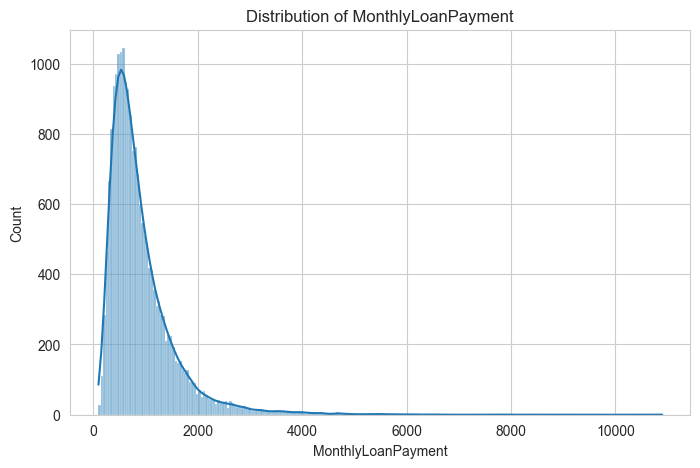

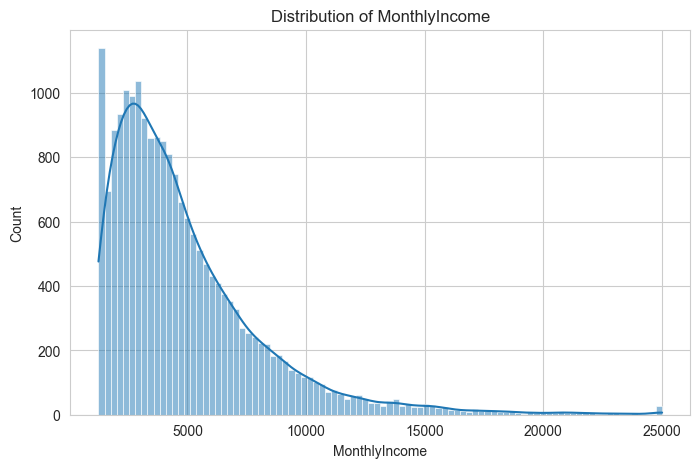

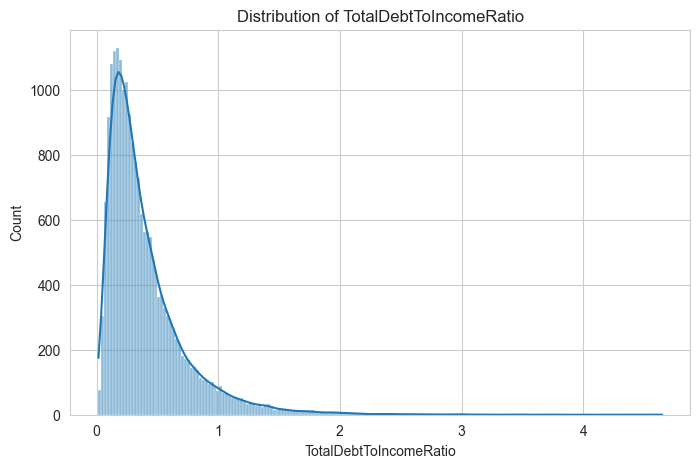

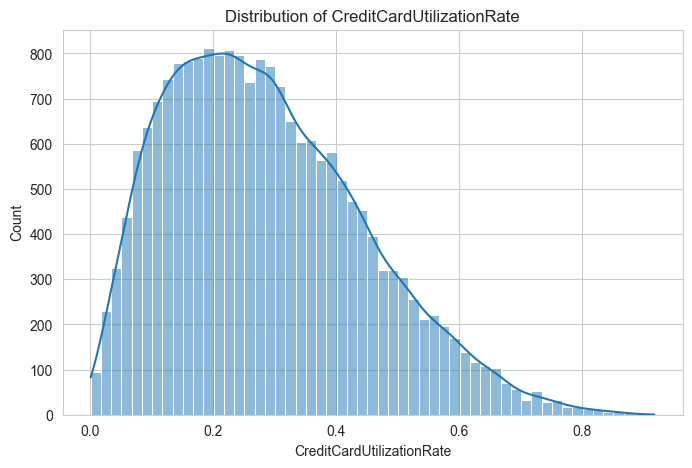

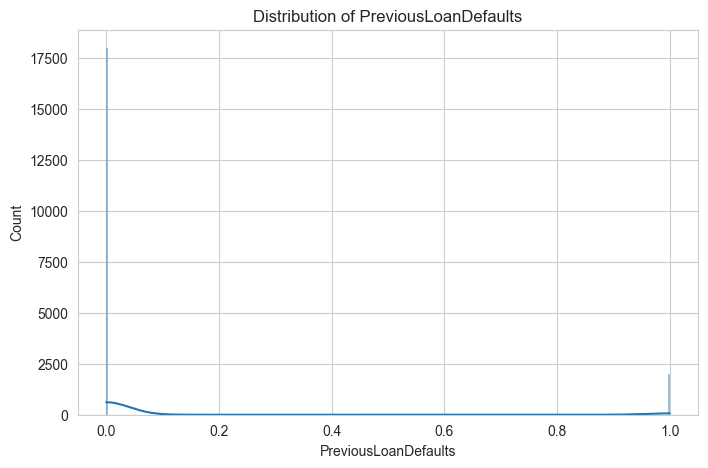

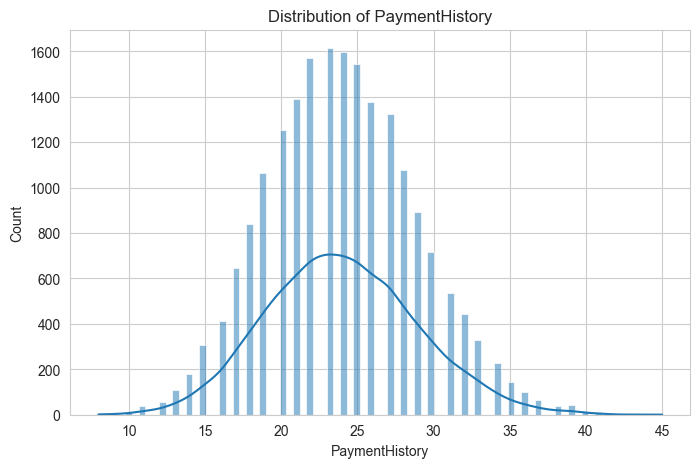

In [16]:
selected_cols = [
    "MonthlyLoanPayment",
    "MonthlyIncome",
    "TotalDebtToIncomeRatio",
    "CreditCardUtilizationRate",
    "PreviousLoanDefaults",
    "PaymentHistory"
]
for col in selected_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Penjelasan Distribusi Data untuk beberapa fitur :
1. Fitur MonthlyLoanPayment
   - Distribusi sangat right-skewed (skew ke kanan). Sebagian besar nilai cicilan bulanan terkonsentrasi pada nilai yang relatif rendah, sementara hanya sedikit nasabah yang memiliki cicilan sangat besar. Bisa diambil kesimpulan bahwa mayoritas nasabah memiliki cicilan bulanan kecil hingga menengah, hanya sedikit nasabah dengan pinjaman besar
   - Mayoritas cicilan berada pada rentang rendah. Frekuensi tertinggi terlihat pada kisaran sekitar 200 – 1500. Ini menunjukkan bahwa sebagian besar nasabah mengambil pinjaman dengan cicilan bulanan yang relatif terjangkau.
   - Kemungkinan terdapat outlier, Nilai cicilan yang sangat tinggi dibandingkan mayoritas data bisa dikategorikan sebagai outlier.
2. Fitur MonthlyIncome
   - Distribusi right-skewed (condong ke kanan). Distribusi pendapatan bulanan terlihat memanjang ke arah kanan, yang berarti sebagian besar nasabah memiliki pendapatan pada tingkat rendah hingga menengah, sementara hanya sebagian kecil yang memiliki pendapatan sangat tinggi.
3. Fitur TotalDebtToIncomeRatio
   - Distribusi sangat right-skewed (condong ke kanan). Sebagian besar nilai rasio hutang terhadap pendapatan berada pada nilai yang rendah, sementara hanya sedikit nasabah yang memiliki rasio yang sangat tinggi. Hal ini menunjukkan bahwa mayoritas nasabah memiliki tingkat hutang yang relatif kecil dibandingkan dengan pendapatan mereka.
4. Fitur CreditCardUtilizationRate.
   - Distribusi CreditCardUtilizationRate terlihat right-skewed (positively skewed) atau miring ke kanan. Sebagian besar data terkonsentrasi di nilai rendah hingga menengah. Terdapat ekor panjang di sisi kanan, yang menunjukkan ada sebagian kecil nasabah dengan utilization rate tinggi. Berarti mayoritas pemegang kartu kredit menggunakan sebagian kecil dari limit kreditnya, sementara hanya sedikit yang menggunakan limit mendekati penuh.
5. Fitur PreviousLoanDefaults
   Merupakan variabel kategorikal biner, yang menunjukkan apakah nasabah pernah mengalami gagal bayar pinjaman sebelumnya.
   0 → Tidak pernah default
   1 → Pernah default

   - Distribusi Data mayoritas data berada pada nilai 0, hanya sebagian kecil observasi pada nilai 1. Berarti sebagian besar nasabah dalam dataset tidak memiliki riwayat gagal bayar sebelumnya, sementara hanya sedikit yang memiliki riwayat default.

6. Fitur PaymentHistory terlihat mendekati normal (bell-shaped distribution). Data membentuk kurva lonceng. Puncak distribusi berada di sekitar nilai 23–25. Distribusi relatif simetris, meskipun sedikit memiliki ekor di kanan, berarti sebagian besar nasabah memiliki riwayat pembayaran pada level menengah.

## Categorical Analysis

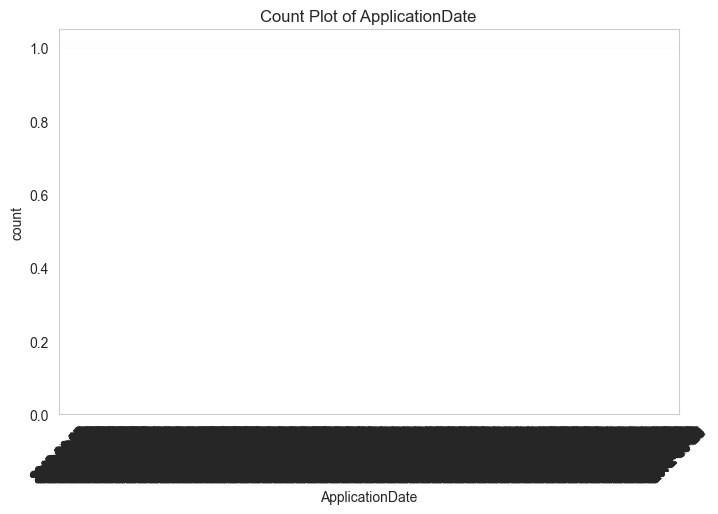

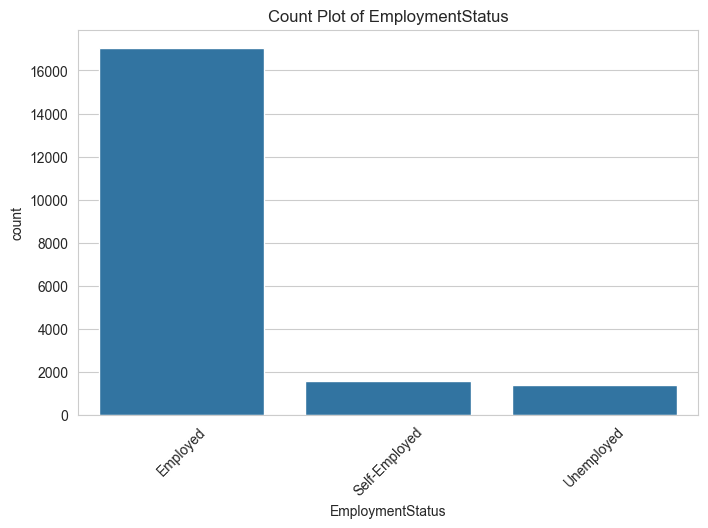

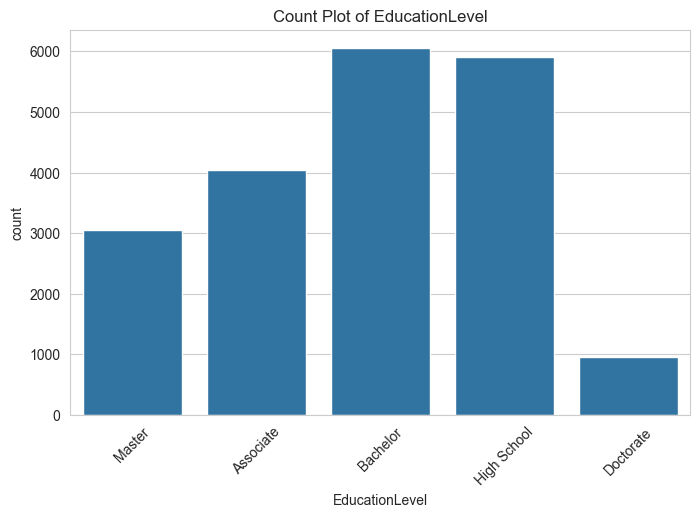

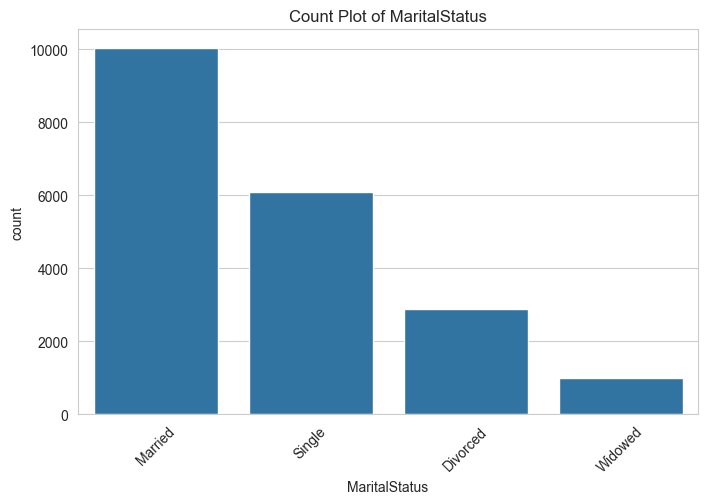

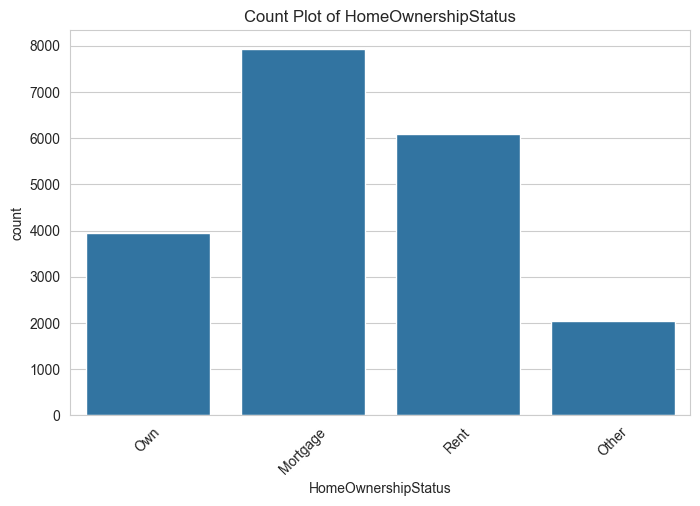

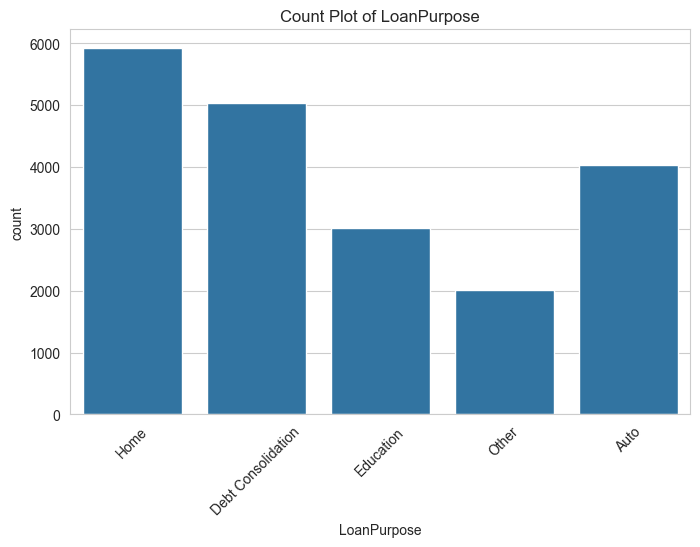

In [12]:
for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Correlation Analysis

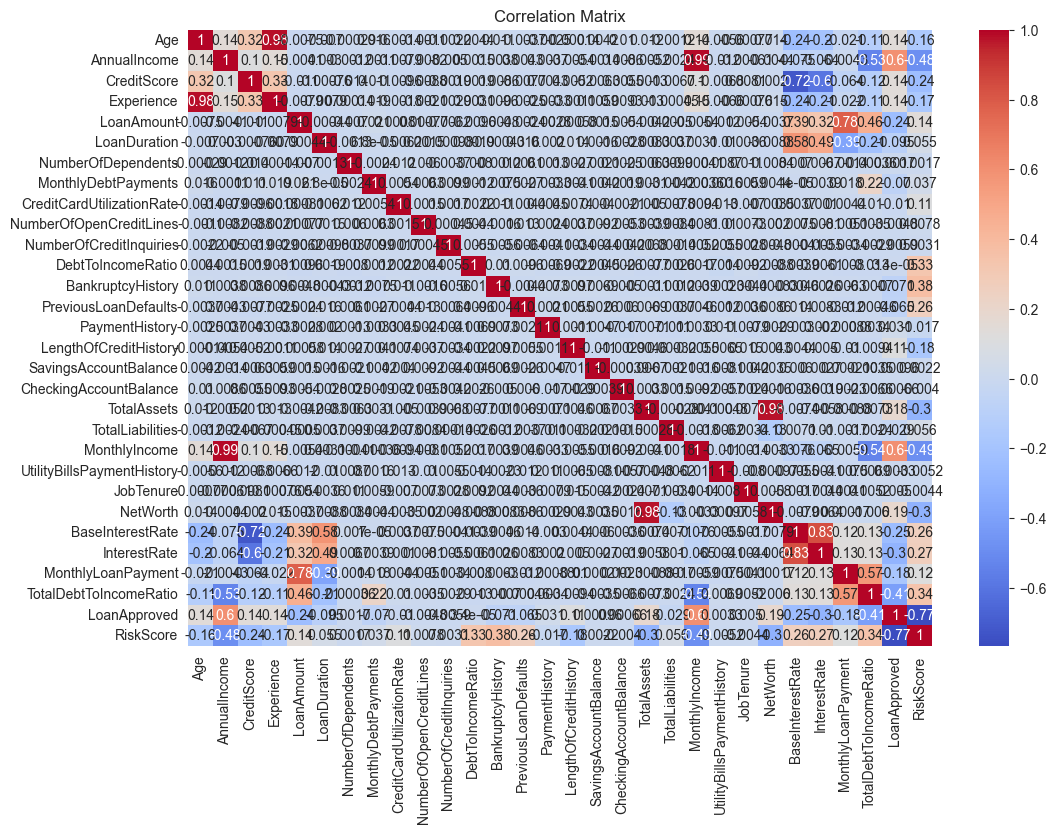

In [13]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Outlier Detection

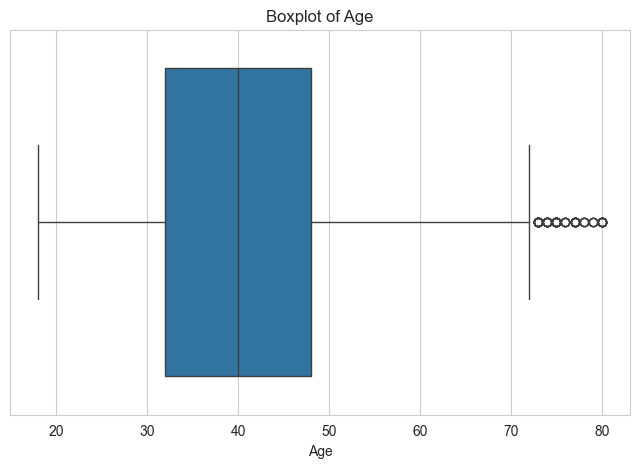

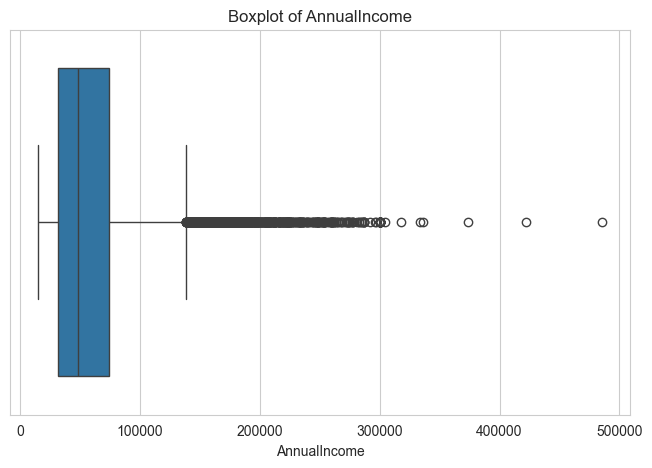

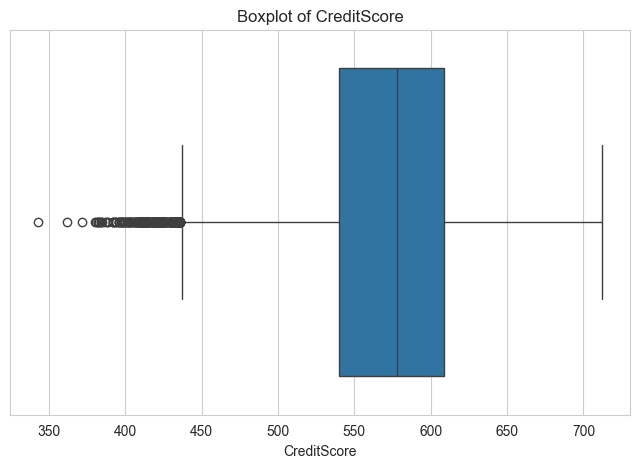

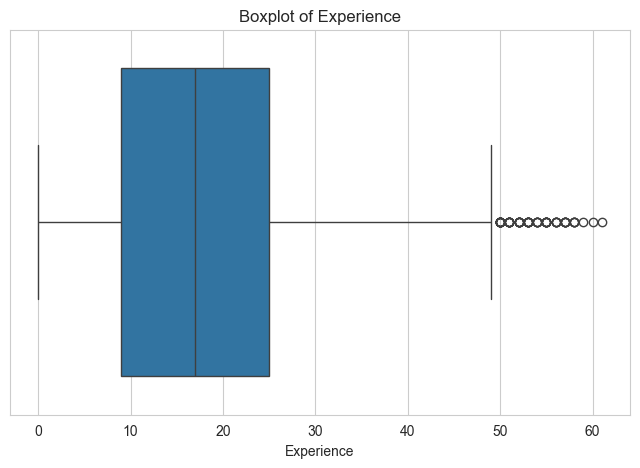

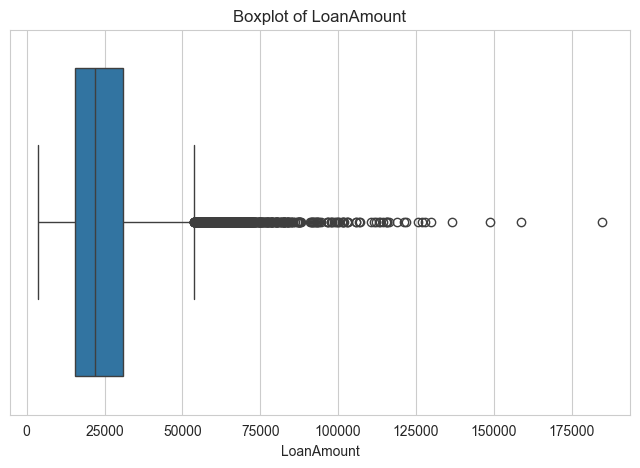

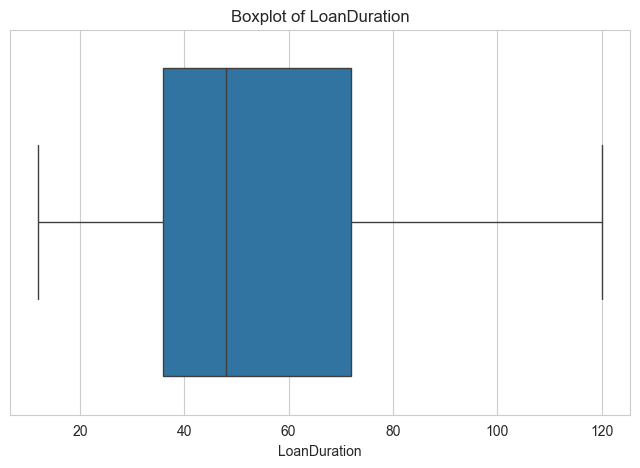

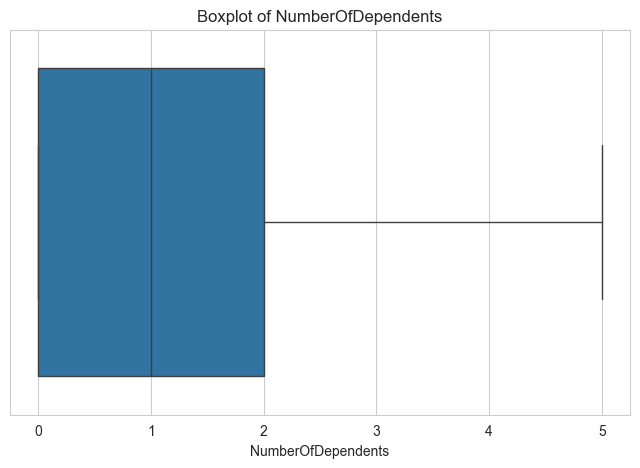

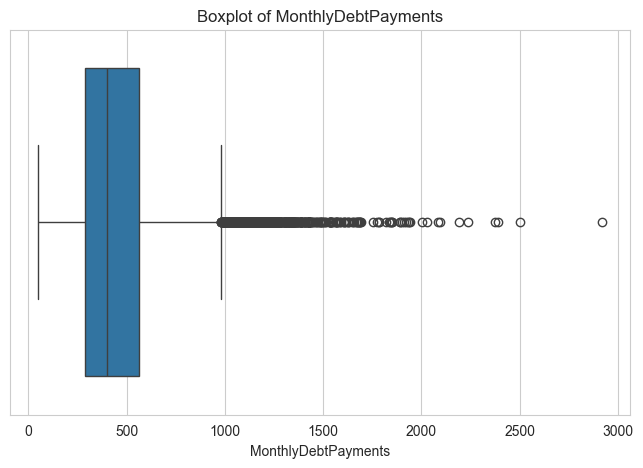

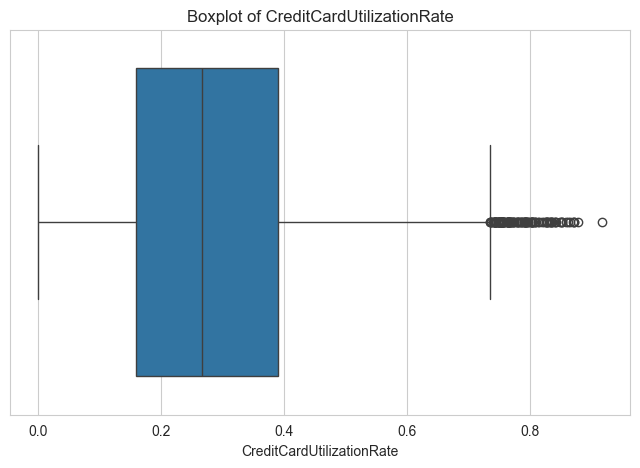

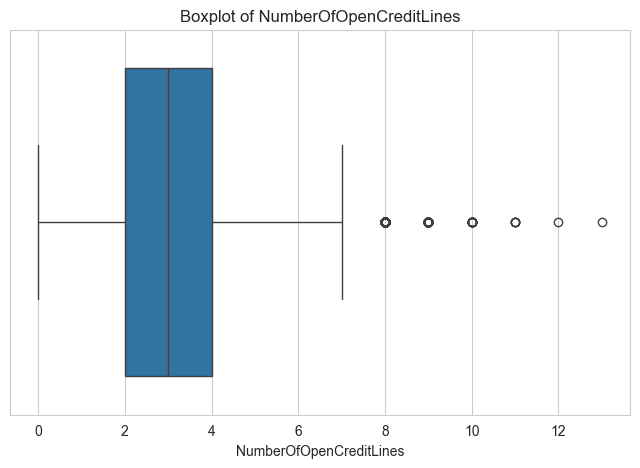

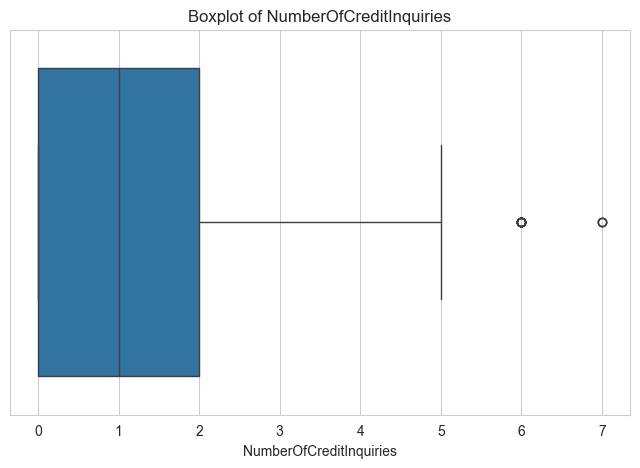

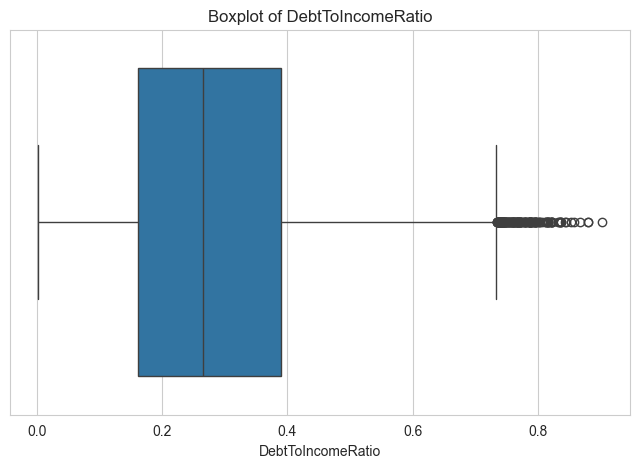

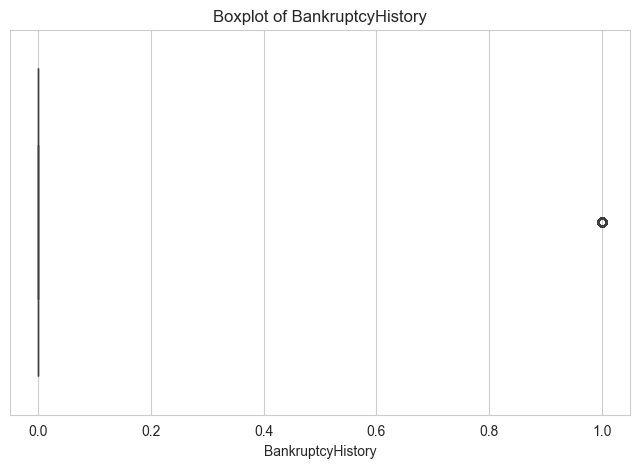

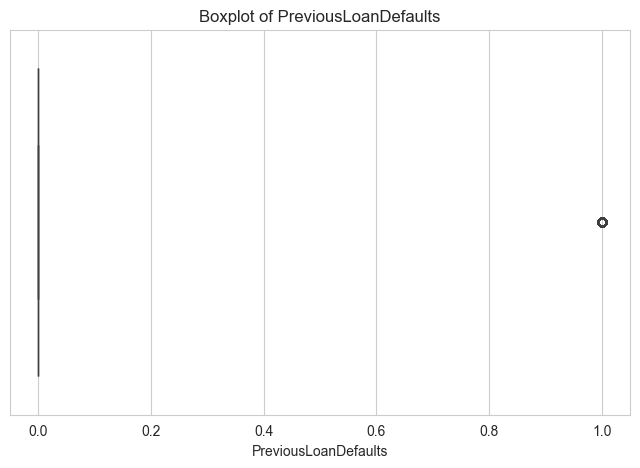

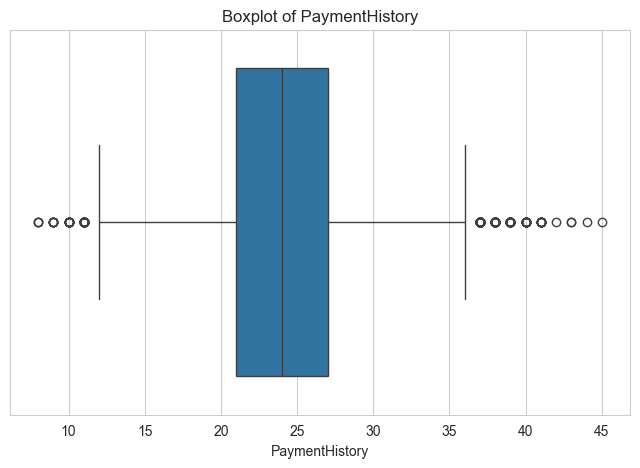

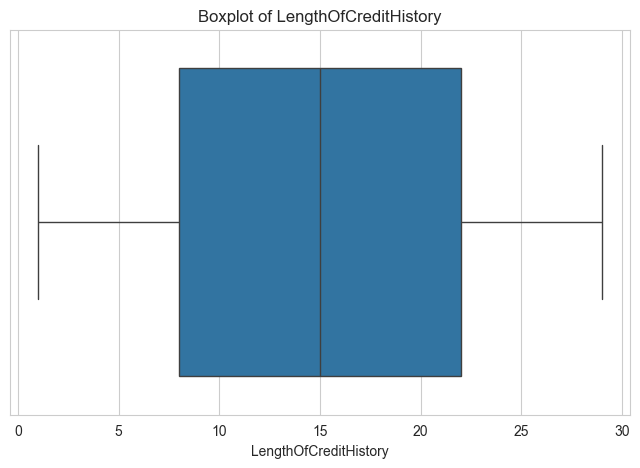

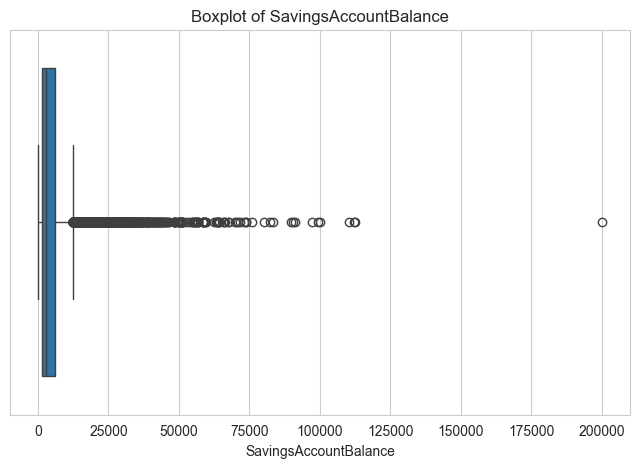

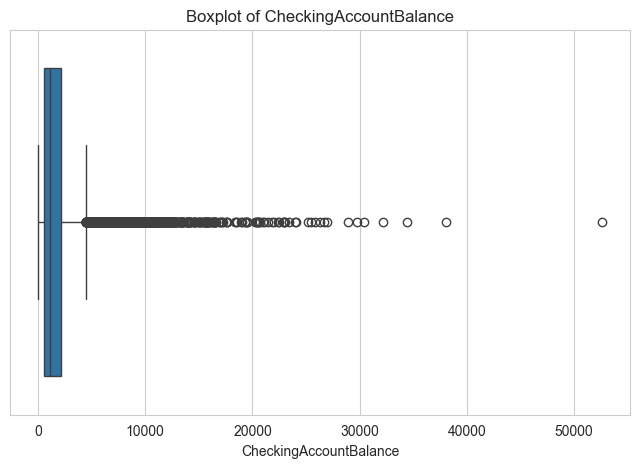

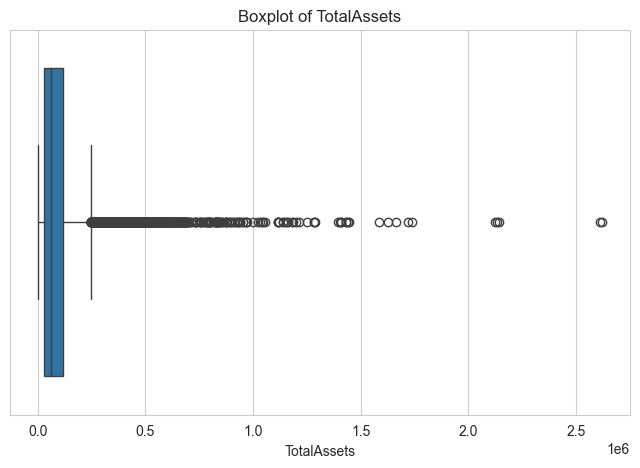

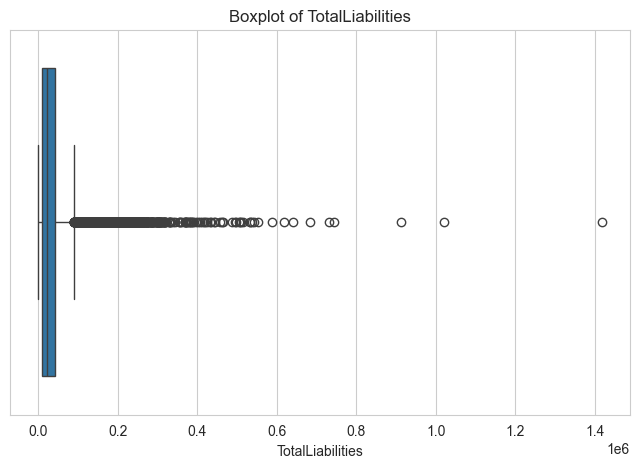

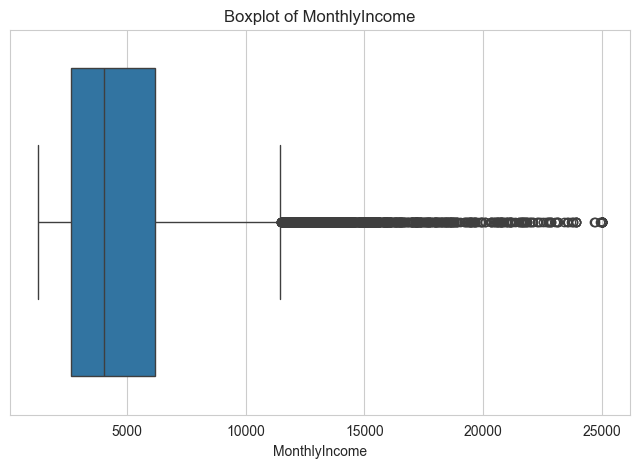

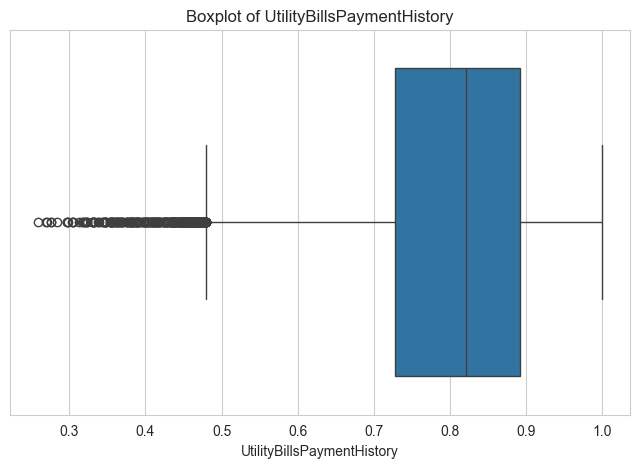

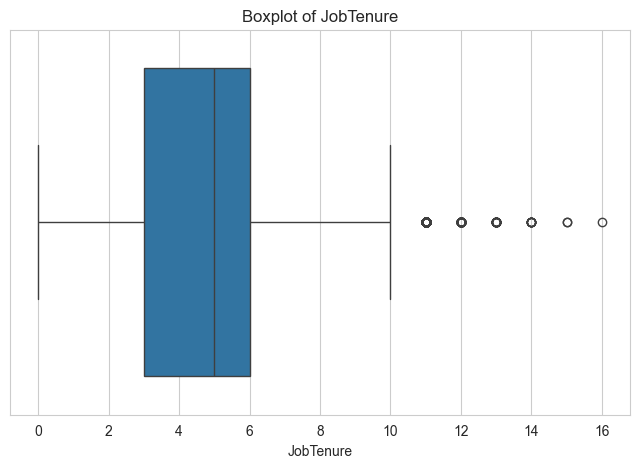

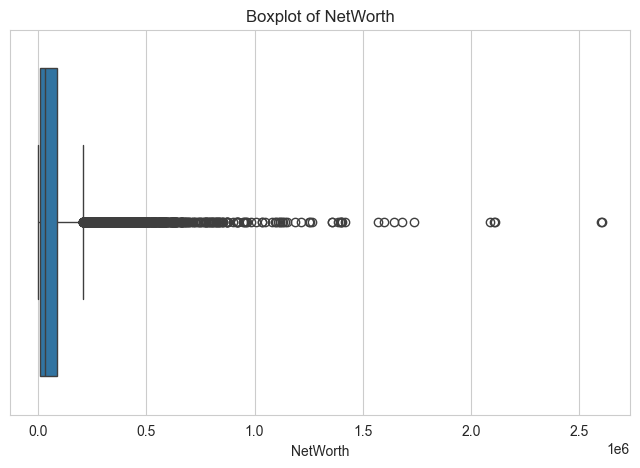

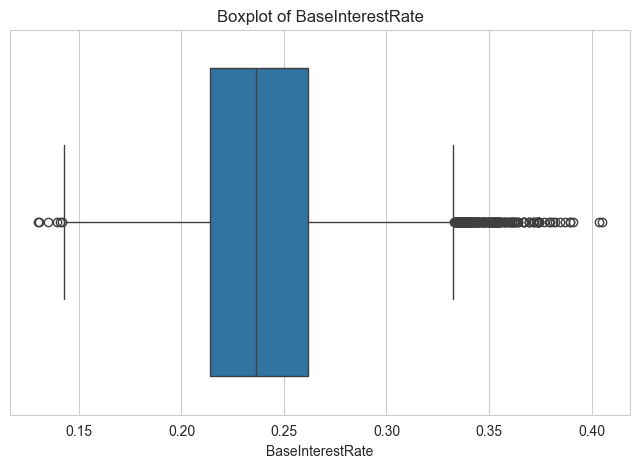

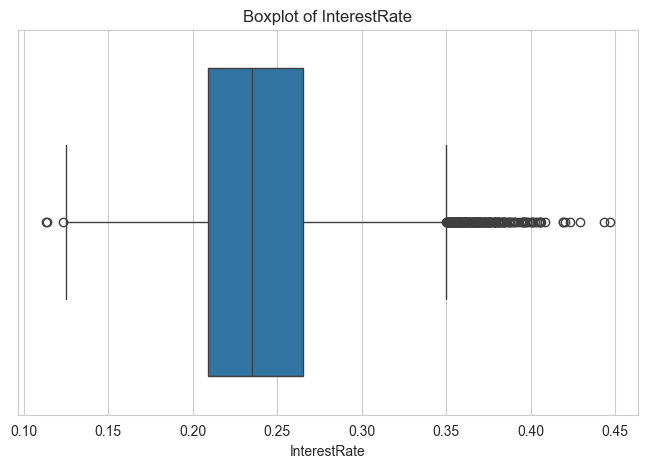

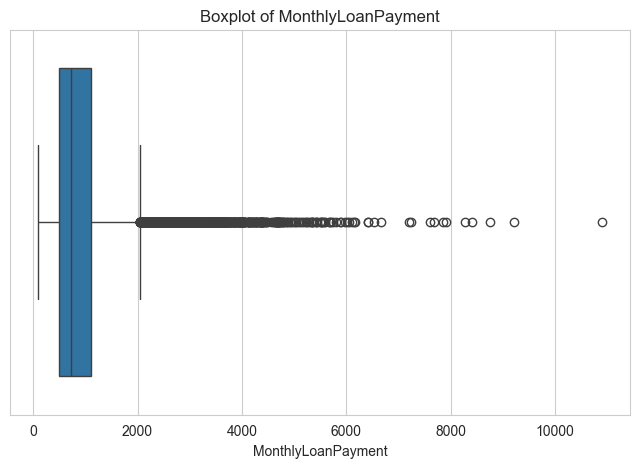

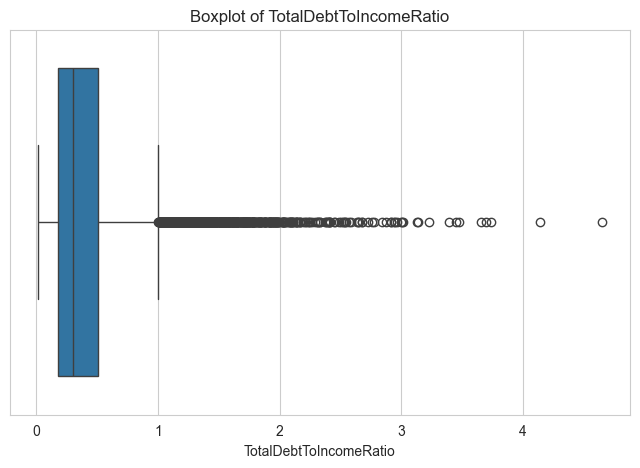

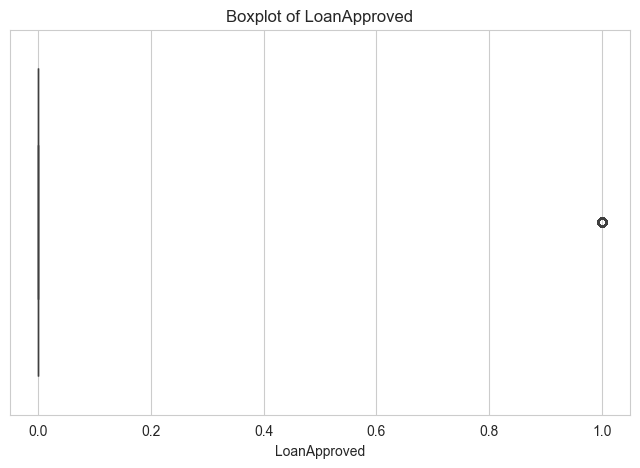

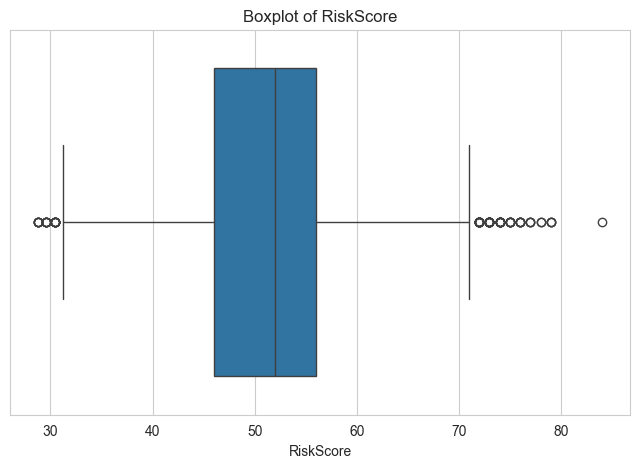

In [14]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Feature Selection

In [11]:
selected_features = [
    "MonthlyLoanPayment",
    "MonthlyIncome",
    "TotalDebtToIncomeRatio",
    "CreditCardUtilizationRate",
    "PreviousLoanDefaults",
    "PaymentHistory",
    "CreditScore",
    "LoanAmount",
    "SavingsAccountBalance",
]

Penjelasan masing fitur

MonthlyLoanPayment
→ jumlah cicilan bulanan

MonthlyIncome
→ kemampuan bayar nasabah

TotalDebtToIncomeRatio
→ rasio hutang terhadap income

CreditCardUtilizationRate
→ penggunaan limit kartu kredit

PreviousLoanDefaults
→ histori gagal bayar

PaymentHistory
→ histori pembayaran

CreditScore
→ indikator utama risiko kredit

LoanAmount
→ besar pinjaman

SavingsAccountBalance
→ kemampuan finansial nasabah

Fitur-fitur ini biasanya paling berpengaruh terhadap credit risk.

## Final Dataset for Modeling

In [ ]:
data = df[selected_features]

data.head()

## Feature Scaling Check

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

scaled_df.head()